# CREDIT CARD RISKS ASSESSMENT MODEL

Content
There are 25 variables:

ID: ID of each client
LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit

SEX: Gender (1=male, 2=female)

EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)

MARRIAGE: Marital status (1=married, 2=single, 3=others)


PAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)

PAY_2: Repayment status in August, 2005 (scale same as above)

PAY_4: Repayment status in June, 2005 (scale same as above)

PAY_5: Repayment status in May, 2005 (scale same as above)

PAY_6: Repayment status in April, 2005 (scale same as above)

BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)

BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)

BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)

BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)

BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)

BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)

PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)

PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)

PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)

PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)

PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)

PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)

default.payment.next.month: Default payment (1=yes, 0=no)


# Importing the necessary libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

In [2]:
df=pd.read_csv('UCI_Credit_Card.csv')
df.head(5)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df.shape

(30000, 25)

In [4]:
# Handle missing values (if any)
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

# Showing how the probability of default payment vary by categories of different demographic variables

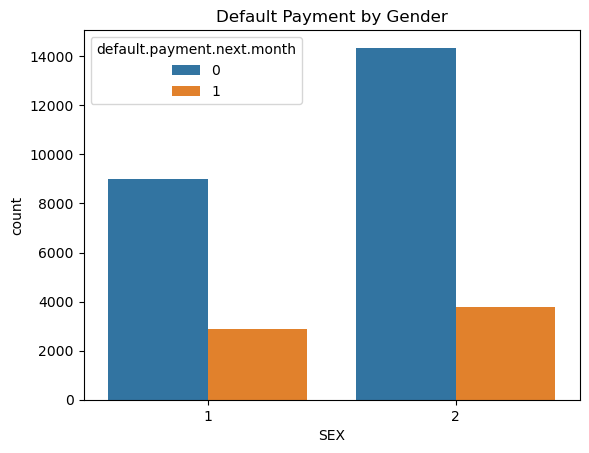

In [5]:
# 1. Gender vs Default Payment
# 1. Gender vs Default Payment
sns.countplot(x='SEX', hue='default.payment.next.month', data=df)
plt.title('Default Payment by Gender')
plt.show()

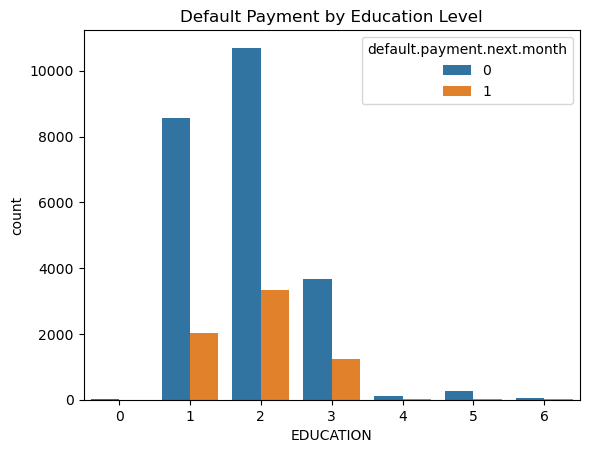

In [6]:
# 2. Education vs Default Payment
sns.countplot(x='EDUCATION', hue='default.payment.next.month', data=df)
plt.title('Default Payment by Education Level')
plt.show()

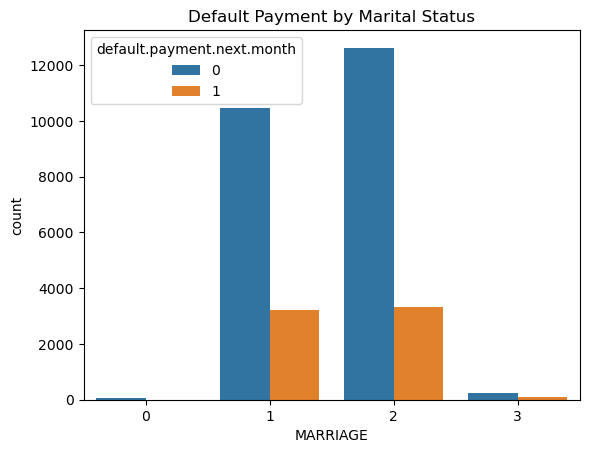

In [7]:
# 3. Marital Status vs Default Payment
sns.countplot(x='MARRIAGE', hue='default.payment.next.month', data=df)
plt.title('Default Payment by Marital Status')
plt.show()

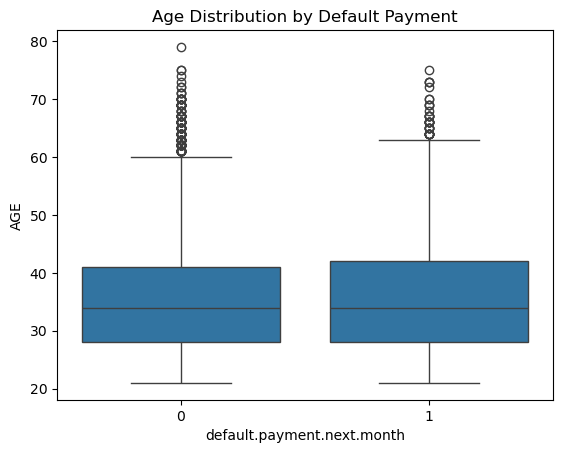

In [8]:
# 4. Age vs Default Payment (Boxplot)
sns.boxplot(x='default.payment.next.month', y='AGE', data=df)
plt.title('Age Distribution by Default Payment')
plt.show()

In [9]:
# Prepare features and target
X = df.drop(columns=['ID', 'default.payment.next.month'])  # Drop ID and target column
y = df['default.payment.next.month']

In [10]:
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Build a Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [12]:
# Make predictions
y_pred = rf_model.predict(X_test)

In [13]:
# Evaluate the model
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.64      0.37      0.47      1313

    accuracy                           0.82      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

Confusion Matrix:
 [[4413  274]
 [ 830  483]]


In [14]:
# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

Accuracy Score: 0.8160


# Features Importance

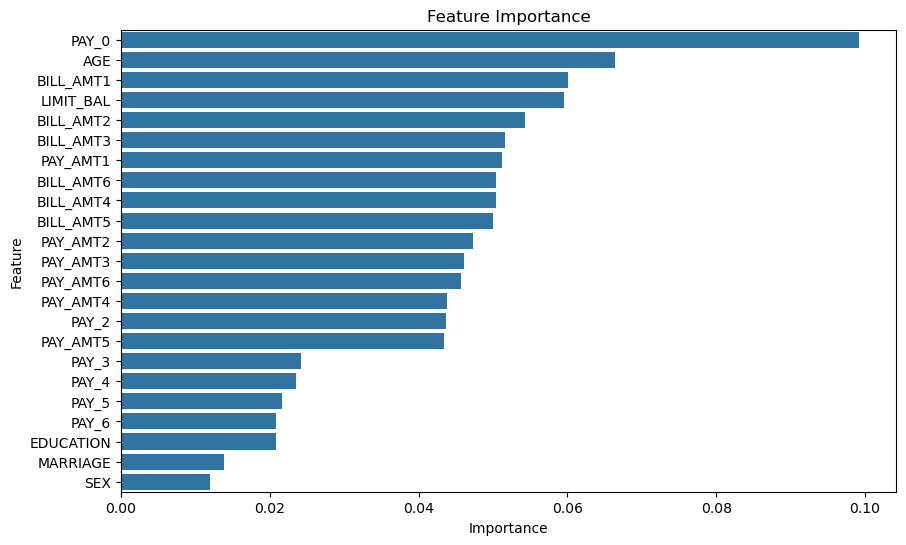

In [15]:
# Part 3: Feature importance to identify strong predictors
feature_importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance')
plt.show()


In [17]:
importances = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)


      Feature  Importance
5       PAY_0    0.099212
4         AGE    0.066405
11  BILL_AMT1    0.060087
0   LIMIT_BAL    0.059578
12  BILL_AMT2    0.054260
13  BILL_AMT3    0.051581
17   PAY_AMT1    0.051233
16  BILL_AMT6    0.050462
14  BILL_AMT4    0.050456
15  BILL_AMT5    0.050036
18   PAY_AMT2    0.047250
19   PAY_AMT3    0.046158
22   PAY_AMT6    0.045641
20   PAY_AMT4    0.043827
6       PAY_2    0.043726
21   PAY_AMT5    0.043370
7       PAY_3    0.024186
8       PAY_4    0.023512
9       PAY_5    0.021689
10      PAY_6    0.020807
2   EDUCATION    0.020770
3    MARRIAGE    0.013808
1         SEX    0.011946


 # Summary of Recommendations for the Bank
 
Look at Payment Behavior, Not Just Background
Instead of relying only on gender, education, or marital status, focus on how people actually manage their credit — like whether they pay on time and how much they spend.

Be Cautious with Certain Groups
Young adults, university students, and single individuals are more likely to miss payments. Offer them lower credit limits at first and increase only if they show good payment habits.

Use Payment History to Spot Risks Early
People who recently missed payments are much more likely to default. Set up alerts to catch these cases early and offer help before it becomes a problem.

Reward Responsible Borrowers
Give better offers, like higher limits or lower interest, to customers who pay on time regularly.

Offer Financial Guidance
Help high-risk customers (like students or singles) with budgeting tools, payment reminders, or basic financial advice to improve their credit habits.










